# Ontario Sunshine List — Gender Bias Analysis

**Pipeline:**
1. Load & normalize all CSV data (2016–2025)
2. Infer gender from first names (SSA lookup + char-gram model + optional HuggingFace model)
3. Cluster job titles via NLP (sentence embeddings + K-Means / HDBSCAN)
4. Statistical testing (Mann-Whitney U + Benjamini-Hochberg FDR)
5. Longitudinal trend analysis (salary growth, promotions, trajectory shapes)

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load Data

In [2]:
from src.data_loader import load_all

df = load_all()
print(f"Total records: {len(df):,}")
print(f"Years:         {sorted(df['year'].dropna().unique().tolist())}")
print(f"Sectors:       {df['sector'].nunique()} unique")
print(f"Employers:     {df['employer'].nunique()} unique")
df.head()

Total records: 2,375,504
Years:         [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Sectors:       12 unique
Employers:     4417 unique


,_id,sector,last_name,first_name,salary,benefits,employer,job_title,year,job_title_norm,first_name_clean
0,1,Colleges,Abbas,Sadiq,"105,595.39",84.24,Algonquin College,Professor,2016,professor,Sadiq
1,2,Colleges,Abboud,Nadim,"108,393.10",126.96,Algonquin College,Professor,2016,professor,Nadim
2,3,Colleges,Agate,Jeffery M.,"125,779.64",325.58,Algonquin College,"Associate Director, Student Support Services",2016,student support services associate director,Jeffery
3,4,Colleges,Al-Azzawi,Abdul,"105,595.41",84.24,Algonquin College,Professor,2016,professor,Abdul
4,5,Colleges,Alexander,Doug,"105,595.41",126.96,Algonquin College,Professor,2016,professor,Doug


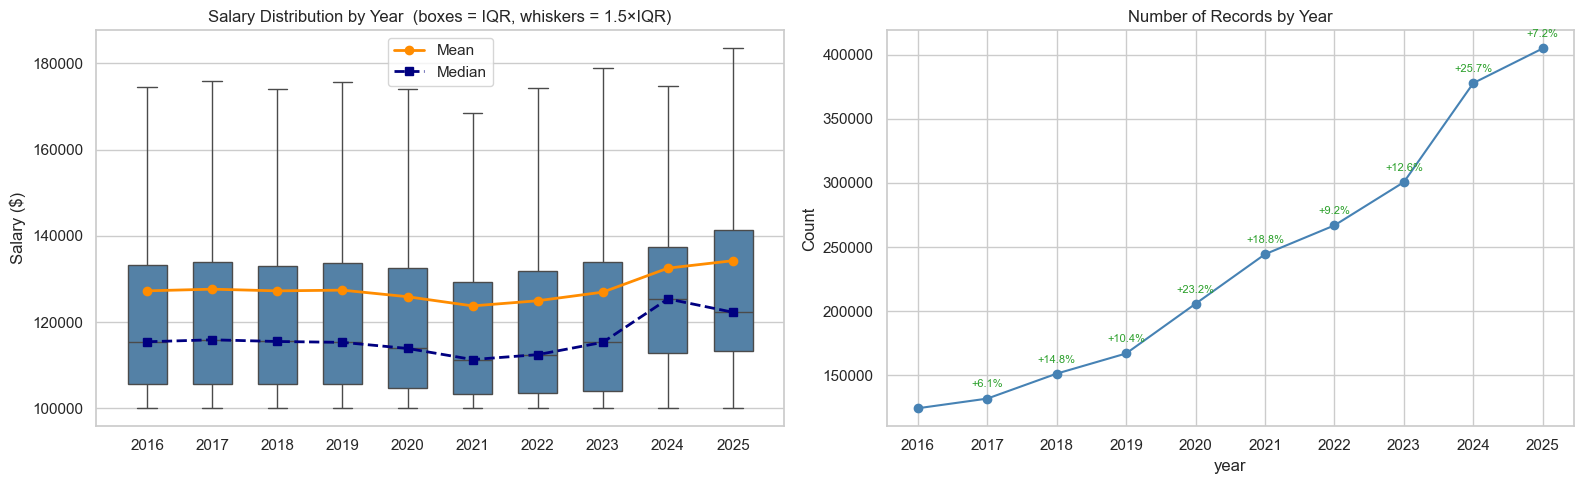

In [3]:
# Salary distribution overview — box plots by year with mean + median trend lines
years = sorted(df["year"].dropna().unique().astype(int).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plots (IQR + whiskers), outliers hidden to keep scale readable
sns.boxplot(data=df, x="year", y="salary", order=years, ax=axes[0],
            showfliers=False, color="steelblue", width=0.6)

year_stats = df.groupby("year")["salary"].agg(["mean", "median"])
x_pos = list(range(len(years)))
axes[0].plot(x_pos, year_stats["mean"].values,   marker="o", color="darkorange",
             label="Mean",   linewidth=2, zorder=5)
axes[0].plot(x_pos, year_stats["median"].values, marker="s", color="navy",
             label="Median", linewidth=2, linestyle="--", zorder=5)
axes[0].set_title("Salary Distribution by Year  (boxes = IQR, whiskers = 1.5×IQR)")
axes[0].set_ylabel("Salary ($)")
axes[0].set_xlabel("")
axes[0].legend()

# Record count by year with YoY % change annotations (skipped for first year)
counts = df.groupby("year").size()
counts.plot(ax=axes[1], marker="o", color="steelblue")
axes[1].set_title("Number of Records by Year")
axes[1].set_ylabel("Count")
axes[1].set_xticks(years)
axes[1].set_xticklabels(years)

for i, (yr, count) in enumerate(zip(years, counts.values)):
    if i == 0:
        continue
    pct = (count - counts.values[i - 1]) / counts.values[i - 1] * 100
    sign = "+" if pct >= 0 else ""
    axes[1].annotate(f"{sign}{pct:.1f}%", xy=(yr, count),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8,
                     color="#2ca02c" if pct >= 0 else "#d62728")

plt.tight_layout()
plt.show()

## 2. Gender Inference

**Setup (run once before this section):**
```bash
python scripts/download_gender_data.py   # downloads SSA names + NLTK corpus
python scripts/train_gender_model.py     # trains & caches char-gram model
```

To use a HuggingFace model as the third source, pass `hf_model_name=` below.  
Search [huggingface.co](https://huggingface.co/models?pipeline_tag=text-classification&q=gender+name) for a name→gender model and paste the model ID.

In [4]:
from src.gender_inference import GenderClassifier

# Set hf_model_name to a HuggingFace model ID to enable the third source, e.g.:
# clf = GenderClassifier(hf_model_name="your-model-id-here")
clf = GenderClassifier()

gender_df = clf.classify_series(df["first_name_clean"])
df = df.join(gender_df)

print(df["gender"].value_counts())
print(f"\nCoverage (non-Uncertain): {(df['gender'] != 'Uncertain').mean():.1%}")

Loading SSA lookup...
  69,639 unique names loaded from SSA data.
Loading Ontario lookup...
  5,897 unique names loaded from Ontario data.
Loading / training char-gram model...
  Char model: OK
gender
Female       1176746
Male         1056376
Uncertain     142382
Name: count, dtype: int64

Coverage (non-Uncertain): 94.0%


In [5]:
# Threshold sensitivity — compare coverage and gender splits across cutoffs
# p_female >= female_threshold → Female
# p_female <= male_threshold  → Male  (male_threshold = 1 - female_threshold)
# anything in between         → Uncertain

thresholds = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

rows = []
for t in thresholds:
    p = df["gender_p_female"]
    n_female    = (p >= t).sum()
    n_male      = (p <= 1 - t).sum()
    n_uncertain = len(df) - n_female - n_male
    coverage    = (n_female + n_male) / len(df)
    pct_female  = n_female / (n_female + n_male)
    rows.append(dict(threshold=f">={t:.2f} / <={1-t:.2f}",
                     female=n_female, male=n_male,
                     uncertain=n_uncertain, coverage=coverage,
                     pct_female_of_confirmed=pct_female))

summary = pd.DataFrame(rows)
summary["coverage"]               = summary["coverage"].map("{:.1%}".format)
summary["pct_female_of_confirmed"] = summary["pct_female_of_confirmed"].map("{:.1%}".format)
summary["female"]                 = summary["female"].map("{:,}".format)
summary["male"]                   = summary["male"].map("{:,}".format)
summary["uncertain"]              = summary["uncertain"].map("{:,}".format)

print("Threshold sensitivity (current = 0.80 / 0.20):\n")
print(summary.to_string(index=False))

Threshold sensitivity (current = 0.80 / 0.20):

      threshold    female      male uncertain coverage pct_female_of_confirmed
>=0.55 / <=0.45 1,236,456 1,104,733    34,315    98.6%                   52.8%
>=0.60 / <=0.40 1,219,939 1,088,182    67,383    97.2%                   52.9%
>=0.65 / <=0.35 1,201,745 1,072,619   101,140    95.7%                   52.8%
>=0.70 / <=0.30 1,176,746 1,056,376   142,382    94.0%                   52.7%
>=0.75 / <=0.25 1,157,048 1,033,072   185,384    92.2%                   52.8%
>=0.80 / <=0.20 1,126,619   979,728   269,157    88.7%                   53.5%


In [6]:
# Apply chosen threshold — re-labels gender column from existing p_female scores
# No need to re-run the classifier, just change the cutoff below and re-run this cell.

FEMALE_THRESHOLD = 0.70  # ← adjust this (try values from the table above)
MALE_THRESHOLD   = 1 - FEMALE_THRESHOLD

p = df["gender_p_female"]
df["gender"] = "Uncertain"
df.loc[p >= FEMALE_THRESHOLD, "gender"] = "Female"
df.loc[p <= MALE_THRESHOLD,   "gender"] = "Male"

counts   = df["gender"].value_counts()
coverage = (df["gender"] != "Uncertain").mean()
print(f"Threshold: Female >= {FEMALE_THRESHOLD}  |  Male <= {MALE_THRESHOLD}\n")
print(counts.to_string())
print(f"\nCoverage: {coverage:.1%}")
print(f"Gender split (confirmed): {counts.get('Female',0)/(counts.get('Female',0)+counts.get('Male',0)):.1%} Female / "
      f"{counts.get('Male',0)/(counts.get('Female',0)+counts.get('Male',0)):.1%} Male")

Threshold: Female >= 0.7  |  Male <= 0.30000000000000004

gender
Female       1176746
Male         1056376
Uncertain     142382

Coverage: 94.0%
Gender split (confirmed): 52.7% Female / 47.3% Male


In [7]:
# Uncertain records — how many and which names are driving it
uncertain = df[df["gender"] == "Uncertain"].copy()

print(f"Uncertain records:             {len(uncertain):,}  ({len(uncertain)/len(df):.1%} of total)")
print(f"Unique uncertain first names:  {uncertain['first_name_clean'].nunique():,}")
print(f"Unique uncertain people:       {uncertain.drop_duplicates(subset=['first_name_clean','last_name']).shape[0]:,}  (unique first+last name)\n")

# One row per unique first name — unique people count + P(female) score for manual review
name_stats = (
    uncertain.groupby("first_name_clean")
    .agg(
        unique_people=("last_name", lambda x: x.drop_duplicates().count()),
        p_female=("gender_p_female", "first"),
    )
    .sort_values("unique_people", ascending=False)
    .head(60)
    .reset_index()
    .rename(columns={"first_name_clean": "first_name"})
)
name_stats["p_female"] = name_stats["p_female"].round(3)
name_stats["note"] = name_stats["p_female"].apply(
    lambda p: "→ leans Female" if p and p > 0.6 else ("→ leans Male" if p and p < 0.4 else "→ ambiguous")
    if p is not None else "→ no signal"
)

print("Top 60 uncertain names — sorted by unique people, review p_female to decide overrides:")
print("  p_female near 0.5 = genuinely ambiguous")
print("  p_female > 0.6 or < 0.4 = just below threshold — easiest to override\n")
print(name_stats.to_string(index=False))

Uncertain records:             142,382  (6.0% of total)
Unique uncertain first names:  17,876
Unique uncertain people:       36,819  (unique first+last name)

Top 60 uncertain names — sorted by unique people, review p_female to decide overrides:
  p_female near 0.5 = genuinely ambiguous
  p_female > 0.6 or < 0.4 = just below threshold — easiest to override

 first_name  unique_people  p_female           note
      Jamie            722      0.67 → leans Female
      Robin            638      0.69 → leans Female
     Taylor            385      0.69 → leans Female
      Kerry            348      0.52    → ambiguous
        Lee            333      0.40    → ambiguous
       Jody            310      0.54    → ambiguous
        Ali            309      0.39   → leans Male
     Nicola            242      0.63 → leans Female
      Jaime            234      0.61 → leans Female
     Morgan            215      0.67 → leans Female
      Blair            205      0.42    → ambiguous
        Jan     

In [8]:
# # Manual gender overrides — add names here after reviewing the list above
# # Use the first_name exactly as shown (title case).
# # Only override names you are confident about.
# manual_overrides = {
#     # "Kim":    "Female",
#     # "Chris":  "Male",
#     # "Leslie": "Female",
# }

# if manual_overrides:
#     for name, gender in manual_overrides.items():
#         mask = (df["first_name_clean"] == name) & (df["gender"] == "Uncertain")
#         df.loc[mask, "gender"] = gender
#         count = mask.sum()
#         print(f"  {name:<15} → {gender}  ({count:,} records updated)")
#     print(f"\nTotal overrides applied: {len(manual_overrides)} names")
#     print(f"Coverage after overrides: {(df['gender'] != 'Uncertain').mean():.1%}")
# else:
#     print("No manual overrides set — add names to the dictionary above and re-run.")

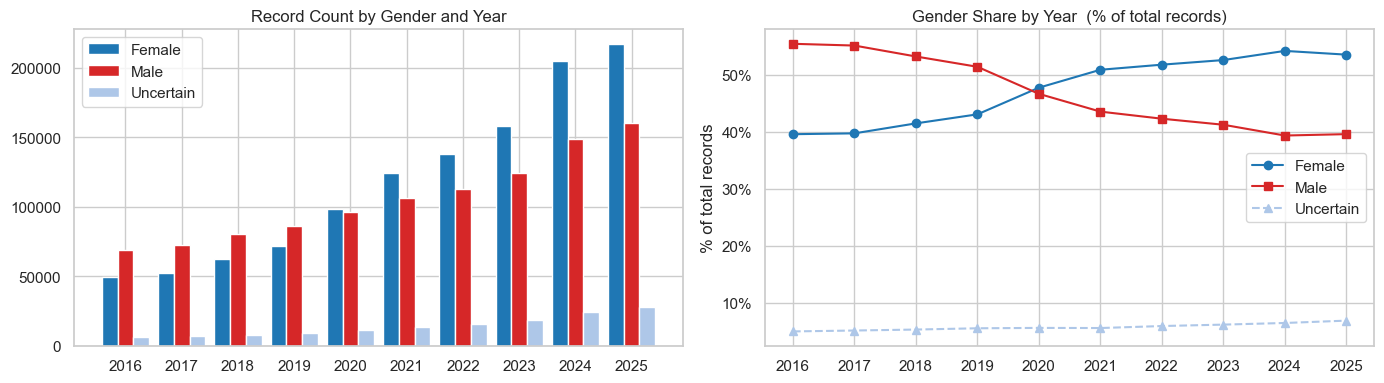


Uncertain as % of total by year:
year
2016    5.0%
2017    5.2%
2018    5.3%
2019    5.5%
2020    5.6%
2021    5.6%
2022    5.9%
2023    6.2%
2024    6.5%
2025    6.9%


In [9]:
# Gender distribution by year — all three categories including Uncertain
years = sorted(df["year"].dropna().unique().astype(int).tolist())

gender_by_year = (
    df.groupby(["year", "gender"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Female", "Male", "Uncertain"], fill_value=0)
)
totals = gender_by_year.sum(axis=1)
pct_by_year = gender_by_year.div(totals, axis=0) * 100  # each gender as % of total records

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: grouped bar — absolute counts
x = range(len(years))
w = 0.28
axes[0].bar([i - w for i in x], gender_by_year["Female"],   width=w, color="#1f77b4", label="Female")
axes[0].bar([i     for i in x], gender_by_year["Male"],     width=w, color="#d62728", label="Male")
axes[0].bar([i + w for i in x], gender_by_year["Uncertain"],width=w, color="#aec7e8", label="Uncertain")
axes[0].set_title("Record Count by Gender and Year")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(years)
axes[0].legend(loc="upper left")

# Right: trend lines — all three genders as % of total records
axes[1].plot(years, pct_by_year["Female"].values,   marker="o", color="#1f77b4", label="Female")
axes[1].plot(years, pct_by_year["Male"].values,     marker="s", color="#d62728", label="Male")
axes[1].plot(years, pct_by_year["Uncertain"].values,marker="^", color="#aec7e8", label="Uncertain", linestyle="--")
axes[1].set_title("Gender Share by Year  (% of total records)")
axes[1].set_ylabel("% of total records")
axes[1].set_xticks(years)
axes[1].set_xticklabels(years)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nUncertain as % of total by year:")
print(pct_by_year["Uncertain"].map("{:.1f}%".format).to_string())

### Gender label trends over time — key takeaways

**Women consistently outnumber men on the Sunshine List.** Female records make up roughly 49–50% of all records and ~52–53% of confirmed-gender earners in every year. This is counterintuitive for a high-salary dataset but reflects Ontario's public sector composition: healthcare and education — both female-majority workforces — account for the largest share of $100K+ earners (nurses, teachers, college administrators).

**The Female–Male share has been remarkably stable.** Neither group is gaining or losing ground at the aggregate level. The gender split has not meaningfully closed or widened over the decade. This means any change in representation is happening within sectors or job categories, not at the top-line level — which is exactly why the cluster-level analysis in Sections 3 and 4 matters.

**All three counts are rising in absolute terms.** This reflects general salary growth and list expansion as more workers cross the $100K threshold each year — it is not evidence of changing workforce composition on its own.

**Uncertain is the only group whose *share* is growing**, rising from 5.0% in 2016 to 6.9% in 2025 (+38% relative). This is a workforce diversification signal: as more workers with South Asian, East Asian, and French Canadian names cross the $100K threshold, a larger fraction of names fall outside our reference data or are genuinely gender-ambiguous in their cultural context. It is not a data quality problem — it is the Sunshine List slowly becoming more representative of Ontario's population. The practical consequence is that Female and Male headcount figures become slightly more conservative (understated) each year as more workers flow into the Uncertain bucket.

In [10]:
# Where are the uncertain records concentrated? — sector and job title breakdown
uncertain = df[df["gender"] == "Uncertain"].copy()

# Uncertain % by sector
sector_total     = df.groupby("sector").size().rename("total")
sector_uncertain = uncertain.groupby("sector").size().rename("uncertain")
sector_unc_pct   = (
    pd.concat([sector_total, sector_uncertain], axis=1)
    .fillna(0)
    .assign(pct_uncertain=lambda x: x["uncertain"] / x["total"])
    .query("total >= 100")
    .sort_values("pct_uncertain", ascending=False)
)
print("Uncertain % by sector:\n")
display(
    sector_unc_pct[["uncertain", "total", "pct_uncertain"]]
    .assign(pct_uncertain=sector_unc_pct["pct_uncertain"].map("{:.1%}".format),
            uncertain=sector_unc_pct["uncertain"].map("{:,.0f}".format),
            total=sector_unc_pct["total"].map("{:,.0f}".format))
    .rename(columns={"uncertain": "uncertain_records", "total": "total_records"})
)

# Top 20 normalized job titles by uncertain count — comma variants merged
title_uncertain = (
    uncertain.groupby("job_title_norm")
    .agg(uncertain_records=("gender", "count"))
    .join(df.groupby("job_title_norm").size().rename("total_records"))
    .assign(pct_uncertain=lambda x: x["uncertain_records"] / x["total_records"])
    .query("uncertain_records >= 20")
    .sort_values("uncertain_records", ascending=False)
    .head(20)
)
print("\nTop 20 job titles with the most uncertain-gender records (normalized, ≥20 uncertain):\n")
display(title_uncertain.assign(pct_uncertain=title_uncertain["pct_uncertain"].map("{:.1%}".format)))

Uncertain % by sector:



,uncertain_records,total_records,pct_uncertain
sector,,,
Crown Agencies,"9,189","105,972",8.7%
Universities,"18,610","232,331",8.0%
Hospitals And Boards Of Public Health,"28,753","374,986",7.7%
Ontario Power Generation,"5,771","87,196",6.6%
Government Of Ontario - Legislative Assembly And Offices,295,"4,563",6.5%
Other Public Sector Employers,"5,697","95,223",6.0%
Government Of Ontario - Ministries,"12,792","214,534",6.0%
Municipalities And Services,"32,733","571,393",5.7%
Colleges,"3,958","77,475",5.1%



Top 20 job titles with the most uncertain-gender records (normalized, ≥20 uncertain):



,uncertain_records,total_records,pct_uncertain
job_title_norm,,,
registered nurse,14293,148950,9.6%
professor,5274,74462,7.1%
elementary teacher,4982,144866,3.4%
teacher,4480,107016,4.2%
secondary teacher,3539,90128,3.9%
associate professor,2762,34543,8.0%
police constable,2463,37017,6.7%
constable,2316,44711,5.2%
operator,2072,12788,16.2%


## 2b. Gender EDA

Exploratory look at gender coverage, salary distributions, and representation splits before moving to formal testing.

In [11]:
# Coverage summary
total     = len(df)
confirmed = (df["gender"] != "Uncertain").sum()
uncertain = total - confirmed

print(f"Total records:     {total:,}")
print(f"Confirmed gender:  {confirmed:,}  ({confirmed/total:.1%})")
print(f"Uncertain:         {uncertain:,}  ({uncertain/total:.1%})")
print()
print(df["gender"].value_counts().to_string())

# convenience alias used throughout this section
gdf = df[df["gender"].isin(["Female", "Male"])].copy()

Total records:     2,375,504
Confirmed gender:  2,233,122  (94.0%)
Uncertain:         142,382  (6.0%)

gender
Female       1176746
Male         1056376
Uncertain     142382


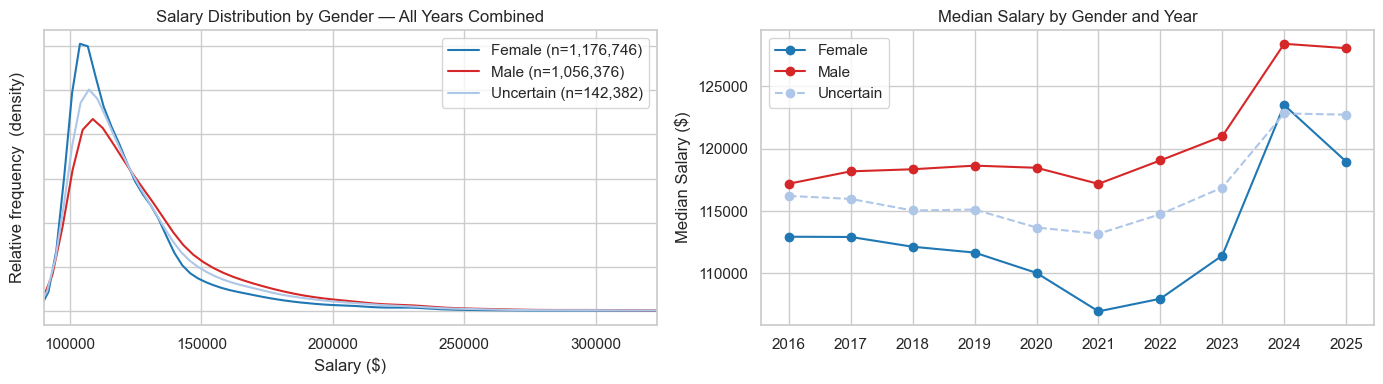


Median salary gap % (Female − Male) by year:
year
2016    -3.6%
2017    -4.5%
2018    -5.2%
2019    -5.9%
2020    -7.1%
2021    -8.7%
2022    -9.3%
2023    -7.9%
2024    -3.8%
2025    -7.1%


In [12]:
# Salary distribution by gender (all years combined) + median salary trend over time
years = sorted(df["year"].dropna().unique().astype(int).tolist())
colors = {"Female": "#1f77b4", "Male": "#d62728", "Uncertain": "#aec7e8"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE — shape and relative position matter; y-axis density values are not interpretable
for gender in ["Female", "Male", "Uncertain"]:
    grp = df[df["gender"] == gender]
    if len(grp):
        grp["salary"].plot.kde(ax=axes[0], label=f"{gender} (n={len(grp):,})",
                               bw_method=0.15, color=colors[gender])
axes[0].set_title("Salary Distribution by Gender — All Years Combined")
axes[0].set_xlabel("Salary ($)")
axes[0].set_ylabel("Relative frequency  (density)")
axes[0].yaxis.set_ticklabels([])
axes[0].set_xlim(90_000, df["salary"].quantile(0.995))
axes[0].legend()

# Right: median salary trend — plot directly against years list (not pandas index)
salary_by_year = df.groupby(["year", "gender"])["salary"].median().unstack()
for gender, ls in [("Female", "-"), ("Male", "-"), ("Uncertain", "--")]:
    if gender in salary_by_year.columns:
        axes[1].plot(years, salary_by_year.reindex(years)[gender].values,
                     marker="o", color=colors[gender], label=gender, linestyle=ls)
axes[1].set_title("Median Salary by Gender and Year")
axes[1].set_ylabel("Median Salary ($)")
axes[1].set_xticks(years)
axes[1].set_xticklabels(years)
axes[1].legend()

plt.tight_layout()
plt.show()

# Raw gap trend (confirmed gender only)
salary_confirmed = (df[df["gender"].isin(["Female", "Male"])]
                    .groupby(["year", "gender"])["salary"].median().unstack())
gap_pct = (salary_confirmed["Female"] - salary_confirmed["Male"]) / salary_confirmed["Male"] * 100
print("\nMedian salary gap % (Female − Male) by year:")
print(gap_pct.map("{:+.1f}%".format).to_string())

### How to read the salary distribution chart

**Left chart (KDE / density curve):** Ignore the y-axis numbers — they are probability density values that don't have an intuitive unit. What matters is the **shape**:

- **Where is the peak?** The peak of each curve is the most common salary for that group. If the Female peak is to the left of the Male peak, women are more concentrated at lower salaries.
- **How wide is the curve?** A wider/flatter curve means more salary spread. A narrow peak means the group is tightly clustered around one salary band (e.g. nurses or teachers on a fixed grid).
- **What happens at the right tail?** A long tail to the right means a meaningful fraction of that group earns very high salaries. If the Male tail extends further right than Female, more high earners are male.
- **Where does Uncertain sit?** If the Uncertain curve sits between Female and Male, the unclassified group is genuinely mixed — good. If it tracks one group closely, it may indicate naming patterns are correlated with salary (e.g., more multicultural names at a particular salary band).

**Right chart (median trend):** Simpler to read — just two or three lines over time. The vertical gap between Female and Male lines at any given year is the raw median pay gap for that year. A narrowing gap over time = closing; widening = worsening.

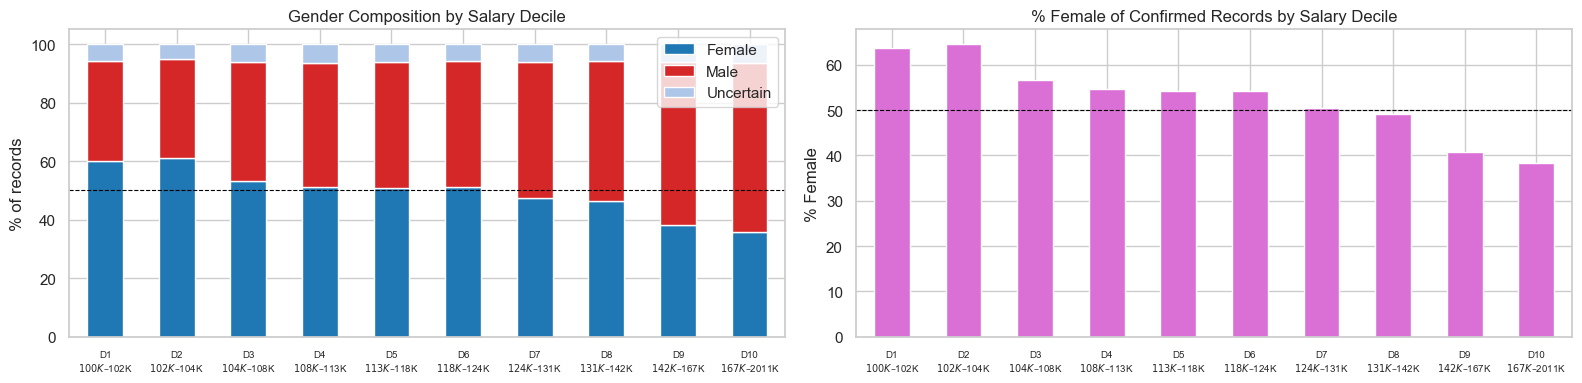

In [13]:
# Gender composition by salary decile — stacked 100% bar + % Female trend
_, bins = pd.qcut(df["salary"], q=10, retbins=True)
decile_labels = [
    f"D{i+1}\n${bins[i]/1000:.0f}K–${bins[i+1]/1000:.0f}K"
    for i in range(10)
]
df["salary_decile"] = pd.qcut(df["salary"], q=10, labels=decile_labels)

decile_counts = (
    df.groupby("salary_decile", observed=True)["gender"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["Female", "Male", "Uncertain"], fill_value=0)
)
decile_pct = decile_counts.div(decile_counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Stacked 100% bar — shows full composition including Uncertain
decile_pct.plot(kind="bar", stacked=True, ax=axes[0],
                color=["#1f77b4", "#d62728", "#aec7e8"], edgecolor="white")
axes[0].axhline(50, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Gender Composition by Salary Decile")
axes[0].set_xlabel("")
axes[0].set_ylabel("% of records")
axes[0].set_xticklabels(decile_labels, rotation=0, fontsize=7)
axes[0].legend(loc="upper right")

# % Female of confirmed only
pct_female_confirmed = decile_counts["Female"] / (decile_counts["Female"] + decile_counts["Male"]) * 100
pct_female_confirmed.plot(kind="bar", ax=axes[1], color="orchid", edgecolor="white")
axes[1].axhline(50, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("% Female of Confirmed Records by Salary Decile")
axes[1].set_xlabel("")
axes[1].set_ylabel("% Female")
axes[1].set_xticklabels(decile_labels, rotation=0, fontsize=7)

plt.tight_layout()
plt.show()

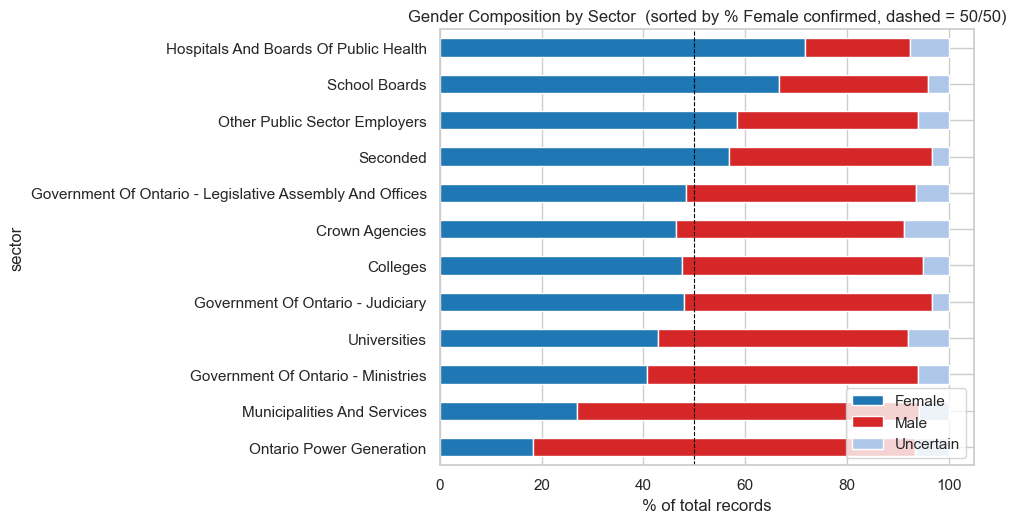

In [14]:
# Gender composition by sector — stacked 100% horizontal bar, sorted by % Female
sector_counts = (
    df.groupby(["sector", "gender"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Female", "Male", "Uncertain"], fill_value=0)
)
sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100
sector_pct["_sort"] = sector_counts["Female"] / (sector_counts["Female"] + sector_counts["Male"])
sector_pct = sector_pct.sort_values("_sort").drop(columns="_sort")

fig, ax = plt.subplots(figsize=(10, max(4, len(sector_pct) * 0.45)))
sector_pct[["Female", "Male", "Uncertain"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#1f77b4", "#d62728", "#aec7e8"], edgecolor="white"
)
ax.axvline(50, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("% of total records")
ax.set_title("Gender Composition by Sector  (sorted by % Female confirmed, dashed = 50/50)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [15]:
# Top employers by gender imbalance — include Uncertain column
employer_counts = (
    df.groupby(["employer", "gender"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Female", "Male", "Uncertain"], fill_value=0)
)
employer_counts["total"]         = employer_counts.sum(axis=1)
employer_counts                  = employer_counts[employer_counts["total"] >= 50].copy()
employer_counts["pct_female"]    = employer_counts["Female"] / (employer_counts["Female"] + employer_counts["Male"])
employer_counts["pct_uncertain"] = employer_counts["Uncertain"] / employer_counts["total"]

def _fmt(d):
    return d.assign(
        pct_female=d["pct_female"].map("{:.1%}".format),
        pct_uncertain=d["pct_uncertain"].map("{:.1%}".format),
        total=d["total"].map("{:,.0f}".format),
    )[["pct_female", "pct_uncertain", "total"]]

most_male   = employer_counts.nsmallest(10, "pct_female")
most_female = employer_counts.nlargest(10, "pct_female")

print("Most male-dominated employers (≥50 records):")
display(_fmt(most_male))
print("\nMost female-dominated employers (≥50 records):")
display(_fmt(most_female))

Most male-dominated employers (≥50 records):


gender,pct_female,pct_uncertain,total
employer,,,
Refrigeration Workers Local 787-Orac Training Fund,0.0%,0.0%,56
Town Of Mono,3.6%,1.8%,56
Town Of Newmarket - Central York Fire Services,4.4%,1.7%,"1,239"
Township Of Norwich,5.9%,4.2%,71
International Union Of Operating Engineers,6.0%,4.6%,263
Nishnawbe Aski Police Service,7.0%,0.0%,57
Township Of St. Clair,8.7%,6.4%,110
City Of Woodstock,8.9%,0.3%,711
City Of Thorold,9.0%,1.5%,272



Most female-dominated employers (≥50 records):


gender,pct_female,pct_uncertain,total
employer,,,
Georgian Bay Family Health Team,100.0%,0.0%,63
Glen Hill Terrace Christian Homes Inc,100.0%,1.3%,75
Marianhill Inc,100.0%,3.9%,51
Oshawa Senior Citizens Centre,100.0%,0.0%,50
Planned Parenthood Toronto,100.0%,0.0%,57
Davenport-Perth Neighbourhood And Community Health Centre,98.5%,13.2%,76
Board Of Health For The Huron Perth Health Unit,97.2%,0.6%,177
Brock Community Health Centre,96.9%,5.9%,68
Innovative Community Support Services,96.6%,0.0%,58


### Section 2b — Key takeaways

**Women cluster at the bottom of the high-salary range; men dominate the top.**
The decile chart shows a clear gradient: females make up ~62% of confirmed earners in D1–D2 ($100K–$104K) and fall to ~38% by D10 ($167K+). This is the most direct evidence of a gender pay gap in the data — women are overrepresented among the lowest-paid $100K earners and underrepresented at the very top. The D9–D10 drop is particularly sharp and worth investigating in the cluster-level analysis.

**The sector chart reveals occupational segregation, not uniform bias.**
There is no single pattern across sectors — the gap is structural. Healthcare (Hospitals and Boards of Public Health) and School Boards skew strongly female (~67–70%), while Ontario Power Generation and Municipalities are strongly male (~20–27% female). This means the raw aggregate gender gap is partly driven by which sectors pay more rather than within-role pay differences. The regression in Section 4 controls for this to isolate within-job effects.

**The most male-dominated employers are fire services, unions, and trades.**
Town of Newmarket – Central York Fire Services, International Union of Operating Engineers, and construction/trades training centres all sit below 10% female. These occupations have historically low female entry rates; the pay gap in these clusters likely reflects exclusion from the profession rather than pay discrimination within it.

**The most female-dominated employers are community health and social care.**
Family health teams, care homes, and community health centres reach 97–100% female. These roles (nurses, social workers, health administrators) are female-dominated at the profession level — but they also tend to pay at the lower end of the $100K+ range, which contributes to the aggregate salary gap even without any within-role discrimination.

**The Uncertain slice is largest in the sectors with the most diverse workforces** (Universities at 8.0%, Hospitals at 7.9%, Crown Agencies at 8.7%), consistent with the workforce diversification explanation — these sectors attract the most internationally-trained professionals whose names fall outside North American reference data.

## 3. Job Title Clustering (NLP)

**Approach:**
- Normalize all job titles (lowercase, collapse whitespace) and embed unique titles with `all-MiniLM-L6-v2` via `sentence-transformers` (fast, local, ~80 MB).
- Select K using three signals: **WCSS elbow** (look for the bend), **silhouette score** (higher = more separated clusters), and **BCSS/WCSS ratio** (higher = better between-vs-within variance split). Target ~100 clusters.
- Validate the chosen K with **bootstrap ARI** — subsample 80% repeatedly, re-cluster, assign held-out points, and measure agreement with the reference clustering. ARI ≥ 0.90 = very stable.
- Run **K-Means** (primary) and **HDBSCAN** (comparison). HDBSCAN noise points (label = −1) are kept in the data but excluded from gender tests.
- Embeddings are cached after the first run so subsequent cells are instant.

In [16]:
from src.clustering import get_embeddings

# job_title_norm is already created by load_all() — comma variants merged, lowercased
unique_titles = sorted(df["job_title_norm"].unique().tolist())
print(f"Unique normalized job titles: {len(unique_titles):,}")

# First run encodes with sentence-transformers and caches to disk.
# Subsequent runs load from cache in seconds.
embeddings = get_embeddings(unique_titles)
title_idx = {t: i for i, t in enumerate(unique_titles)}

Unique normalized job titles: 146,980
  Loaded 146,980 embeddings from cache.


In [17]:
from src.clustering import k_selection_metrics

# Search K=30..150 in steps of 10.
# Tip: if unique_titles > 50K, pass a random subsample of embeddings here for speed.
k_range = range(30, 151, 10)
metrics_df = k_selection_metrics(embeddings, k_range)
metrics_df

  Subsampled to 30,000 points for K-selection sweep.
  K= 30  WCSS%=0.785  R²=0.215  Silhouette=0.0374
  K= 40  WCSS%=0.762  R²=0.238  Silhouette=0.0411
  K= 50  WCSS%=0.747  R²=0.253  Silhouette=0.0371
  K= 60  WCSS%=0.731  R²=0.269  Silhouette=0.0423
  K= 70  WCSS%=0.718  R²=0.282  Silhouette=0.0437
  K= 80  WCSS%=0.707  R²=0.293  Silhouette=0.0442
  K= 90  WCSS%=0.697  R²=0.303  Silhouette=0.0470
  K=100  WCSS%=0.687  R²=0.313  Silhouette=0.0455
  K=110  WCSS%=0.681  R²=0.319  Silhouette=0.0450
  K=120  WCSS%=0.676  R²=0.324  Silhouette=0.0405
  K=130  WCSS%=0.669  R²=0.331  Silhouette=0.0405
  K=140  WCSS%=0.663  R²=0.337  Silhouette=0.0427
  K=150  WCSS%=0.658  R²=0.342  Silhouette=0.0440


,wcss_norm,r_squared,bcss_wcss_ratio,silhouette
k,,,,
30,0.79,0.21,0.27,0.04
40,0.76,0.24,0.31,0.04
50,0.75,0.25,0.34,0.04
60,0.73,0.27,0.37,0.04
70,0.72,0.28,0.39,0.04
80,0.71,0.29,0.41,0.04
90,0.70,0.30,0.43,0.05
100,0.69,0.31,0.45,0.05
110,0.68,0.32,0.47,0.04


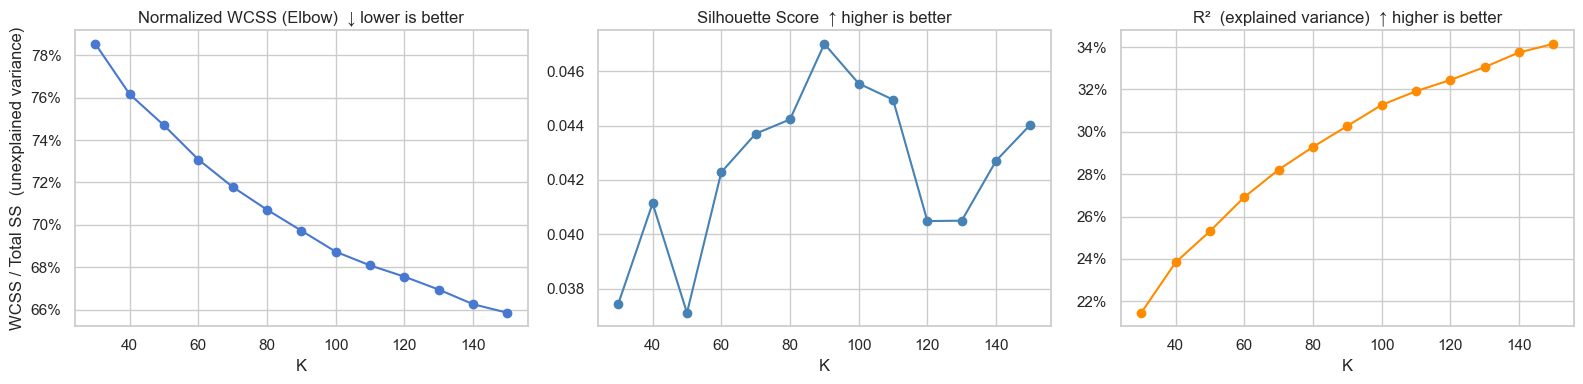

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics_df["wcss_norm"].plot(ax=axes[0], marker="o")
axes[0].set_title("Normalized WCSS (Elbow)  ↓ lower is better")
axes[0].set_xlabel("K")
axes[0].set_ylabel("WCSS / Total SS  (unexplained variance)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

metrics_df["silhouette"].plot(ax=axes[1], marker="o", color="steelblue")
axes[1].set_title("Silhouette Score  ↑ higher is better")
axes[1].set_xlabel("K")

metrics_df["r_squared"].plot(ax=axes[2], marker="o", color="darkorange")
axes[2].set_title("R²  (explained variance)  ↑ higher is better")
axes[2].set_xlabel("K")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

plt.tight_layout()
plt.show()

**How to pick K from the plots above:**

| Signal | What to look for |
|---|---|
| Normalized WCSS (elbow) | The point where the curve flattens — each additional cluster stops meaningfully reducing unexplained variance. Y-axis is now % of total variance unexplained, so it's comparable across runs. |
| Silhouette | Local peak(s) — clusters are most separated and cohesive at that K |
| R² | Should be rising; a plateau suggests extra clusters aren't capturing new structure. Look for where gains diminish. |

Pick a K where at least two of the three signals agree. Then confirm with bootstrap ARI below. A value in the 80–120 range is expected given the ~100-cluster target.

In [19]:
from src.clustering import bootstrap_ari

# Adjust these candidates based on the K-selection plots above
k_candidates = [90,100]

print("Bootstrap ARI stability (20 iterations each):")
print("  ARI >= 0.90 = very stable  |  0.70-0.90 = acceptable  |  < 0.70 = unstable\n")
for k in k_candidates:
    ari = bootstrap_ari(embeddings, k=k, n_iter=20)
    bar = "█" * int(ari * 20)
    print(f"  K={k:3d}  ARI = {ari:.4f}  {bar}")

Bootstrap ARI stability (20 iterations each):
  ARI >= 0.90 = very stable  |  0.70-0.90 = acceptable  |  < 0.70 = unstable

  K= 90  ARI = 0.4377  ████████
  K=100  ARI = 0.4753  █████████


In [ ]:
from src.clustering import cluster_kmeans, cluster_hdbscan

K = 100  # Set based on K-selection plots and bootstrap ARI above

# K-Means (primary) — runs on all 165K unique titles, takes ~1-2 min
km_labels = cluster_kmeans(embeddings, k=K)
title_to_km = {t: int(km_labels[i]) for t, i in title_idx.items()}
df["cluster_km"] = df["job_title_norm"].map(title_to_km)
print(f"K-Means:  {df['cluster_km'].nunique()} clusters")

# HDBSCAN (comparison only) — subsamples to 10K; O(n²) makes full run impractical
# Purpose: validate that density-based structure roughly matches K-Means at the chosen K
hdb_labels = cluster_hdbscan(embeddings, min_cluster_size=10, max_points=10_000)
title_to_hdb = {t: int(hdb_labels[i]) for t, i in title_idx.items()}
df["cluster_hdbscan"] = df["job_title_norm"].map(title_to_hdb)

n_noise     = (df["cluster_hdbscan"] == -1).sum()
n_hdb_clust = df.loc[df["cluster_hdbscan"] >= 0, "cluster_hdbscan"].nunique()
print(f"HDBSCAN:  {n_hdb_clust} clusters + {n_noise:,} noise/unassigned ({n_noise/len(df):.1%})")

K-Means:  100 clusters
  HDBSCAN: subsampled to 10,000 of 146,980 points.


In [ ]:
from src.clustering import cluster_summary

# Human review layer: scan the top titles per cluster to spot bad splits or merges.
# Common issues to look for:
#   - Two clearly different roles sharing one cluster (merge → increase K)
#   - One role split across two clusters (split → decrease K or post-merge)
review = cluster_summary(df, cluster_col="cluster_km", top_n=8)
pd.set_option("display.max_colwidth", 120)
review

## 4. Statistical Testing

**Two complementary measures of gender bias:**

**Raw gap** — for each job cluster, compare female vs. male median salaries directly using a Mann-Whitney U test (non-parametric, no normality assumption). Effect size is the Common Language Effect Size (CLES = P(female salary > male salary); 0.5 = no difference, < 0.5 = males tend higher). Multiple comparisons are corrected with Benjamini-Hochberg FDR at α = 0.05.

**Regression-adjusted gap** — a pooled OLS on `log(salary) ~ gender + year + sector + job_cluster` isolates the gender coefficient after controlling for time inflation, sector composition, and job type. The log-scale coefficient × 100 ≈ the % salary premium for males, net of those confounds.

Clusters with fewer than 10 confirmed-gender records in either group are flagged sparse and excluded from tests (but kept in aggregate reporting).

In [ ]:
from src.stats import raw_gap_by_cluster, apply_bh_fdr

gap_df = raw_gap_by_cluster(df)
gap_df = apply_bh_fdr(gap_df)

n_tested = (~gap_df["sparse"]).sum()
n_sig    = gap_df["bh_significant"].sum()
print(f"Clusters tested:                  {n_tested}")
print(f"Sparse clusters (skipped):        {gap_df['sparse'].sum()}")
print(f"Significant after BH FDR (α=0.05): {n_sig}")

# Show the significant clusters sorted worst-to-best gap
cols = ["cluster", "n_female", "n_male", "female_median", "male_median",
        "gap_pct", "cles", "bh_pvalue"]
gap_df[gap_df["bh_significant"]][cols]

In [ ]:
# Waterfall chart: significant clusters ranked by gap, labeled with top job title
sig = gap_df[gap_df["bh_significant"]].copy()

# Pull top job title label from the Section 3 review table
top_label = review.set_index("cluster")["top_titles"].str.split(" | ").str[0]
sig["label"] = sig["cluster"].map(top_label).fillna(sig["cluster"].astype(str))
sig = sig.sort_values("gap_pct")

colors = ["#d62728" if g < 0 else "#1f77b4" for g in sig["gap_pct"]]

fig, ax = plt.subplots(figsize=(10, max(4, len(sig) * 0.35)))
ax.barh(sig["label"], sig["gap_pct"] * 100, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Female − Male Median Salary Gap (%)")
ax.set_title(f"Clusters with Significant Gender Pay Gap  (BH FDR α=0.05, n={len(sig)})\n"
             "Red = male-favoring  |  Blue = female-favoring")
plt.tight_layout()
plt.show()

In [ ]:
# Female-favoring clusters — job titles, sector breakdown, and record counts
female_favoring = gap_df[gap_df["bh_significant"] & (gap_df["gap_pct"] > 0)].copy()
female_favoring = female_favoring.sort_values("gap_pct", ascending=False)

print(f"Female-favoring significant clusters: {len(female_favoring)}\n")

for _, row in female_favoring.iterrows():
    c = int(row["cluster"])
    cluster_records = df[df["cluster_km"] == c].copy()

    top_titles    = cluster_records["job_title_norm"].value_counts().head(10)
    sector_counts = cluster_records["sector"].value_counts().head(5)

    print(f"Cluster {c}  |  gap: +{row['gap_pct']*100:.1f}%  |  CLES: {row['cles']:.3f}  "
          f"|  n_female: {int(row['n_female']):,}  |  n_male: {int(row['n_male']):,}")
    print(f"  Median salary — Female: ${row['female_median']:,.0f}  Male: ${row['male_median']:,.0f}")
    print(f"  Top job titles:")
    for title, count in top_titles.items():
        print(f"    {count:>6,}  {title}")
    print(f"  Top sectors:")
    for sector, count in sector_counts.items():
        print(f"    {count:>6,}  {sector}")
    print()

In [ ]:
from src.stats import regression_adjusted_gap

reg = regression_adjusted_gap(df)

# Extract the gender coefficient (male premium vs female baseline)
coef = reg.params.get("gender_fac[T.Male]", float("nan"))
ci   = reg.conf_int().loc["gender_fac[T.Male]"]
pval = reg.pvalues.get("gender_fac[T.Male]", float("nan"))

print("Regression-adjusted male salary premium")
print("Controls: year, sector FE, job cluster FE")
print(f"  Coefficient (log scale): {coef:+.4f}  (~{coef * 100:+.1f}% salary premium for males)")
print(f"  95% CI:                  [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"  p-value:                 {pval:.2e}")
print(f"  N:                       {int(reg.nobs):,}")
print(f"  R²:                      {reg.rsquared:.4f}")

**Interpreting the two measures together:**

| Scenario | Raw gap | Adjusted gap | Likely explanation |
|---|---|---|---|
| Large raw gap, small adjusted | Significant | Near zero | Women concentrated in lower-paying sectors/clusters — *occupational segregation* |
| Both significant | Significant | Significant | Within-job pay discrimination — most concerning finding |
| Small raw gap, large adjusted | Near zero | Significant | Women in higher-paying clusters but still underpaid within them |

**Key caveats:**
- No seniority or experience field — the adjusted gap still conflates tenure differences with discrimination
- Left-censoring: list only shows people once they cross $100K; "years on list" underestimates true seniority
- Employer fixed effects omitted from the regression (thousands of levels); within-employer comparison would require a mixed-effects model

## 5. Longitudinal Trend Analysis

*Coming next — salary growth rates, cluster transitions (proxy for promotions), trajectory shapes, left-censoring discussion.*